<a href="https://colab.research.google.com/github/asheta66/Machine-Learning-2024/blob/main/OSA/ENN_for_OSA_Data_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

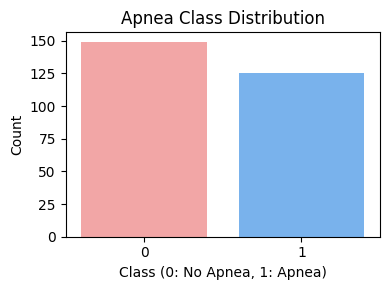

In [138]:
# ==========================================================
# 1. IMPORT LIBRARIES
# ==========================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score
)

np.random.seed(42)

# Create folder for figures
import os
os.makedirs("figures", exist_ok=True)

# ==========================================================
# 2. USER-TUNABLE PARAMETERS
# ==========================================================
N_HIDDEN = 30
POP_SIZE = 30
ITERATIONS = 150

# GA parameters
CROSS_RATE = 0.85
MUT_RATE = 0.001

# PSO parameters
W = 0.5
C1 = 1.5
C2 = 1.5

# ==========================================================
# 3. LOAD & PREPROCESS DATA
# ==========================================================
df = pd.read_csv("sleep-apnea-data-2025.csv")

X = df.drop(columns=["apnea"]).values
y = df["apnea"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.25, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ==========================================================
# 4. DATA VISUALIZATION
# ==========================================================
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(4,3))
sns.countplot(
    x=y,
    hue=y,                       # assign x to hue
    palette=['#FF9999', '#66B2FF'],
    legend=False      # remove duplicate legend
)
plt.title("Apnea Class Distribution")
plt.xlabel("Class (0: No Apnea, 1: Apnea)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("figures/class_distribution.png", dpi=300)
plt.show()

In [139]:
df.describe()

,Race,Age,Sex,BMI,Epworth,Wast,Hip,RDI,Neck,M.Friedman,...,Apnea Index,Hypopnea Index,Berlin Q,Arousal index,Awakening Index,PLM Index,Mins.SaO2,Mins.SaO2Desats,Lowest Sa02,apnea
count,274.000000,274.000000,274.000000,274.000000,274.000000,274.000000,274.000000,274.000000,274.000000,274.000000,...,274.000000,274.000000,274.000000,274.000000,274.000000,274.000000,274.000000,274.000000,274.000000,274.000000
mean,0.448905,0.602190,0.569343,3.580292,10.306569,42.696565,44.784483,17.619343,16.293613,2.598540,...,8.170440,9.319708,1.864964,33.384307,2.892336,17.554197,22.972007,9.100365,81.857664,0.456204
std,0.498293,0.490341,0.496074,0.686696,5.605547,7.199824,11.345949,20.807977,1.998013,1.048004,...,15.383789,11.216996,0.342388,21.403743,1.988643,28.013497,45.102124,24.312124,10.768481,0.498990
min,0.000000,0.000000,0.000000,1.000000,0.000000,25.000000,26.000000,0.000000,11.000000,1.000000,...,0.000000,0.000000,1.000000,3.400000,0.200000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,3.000000,6.000000,38.000000,39.250000,2.600000,15.000000,2.000000,...,0.100000,1.425000,2.000000,17.850000,1.800000,0.600000,0.400000,0.000000,77.175000,0.000000
50%,0.000000,1.000000,1.000000,4.000000,10.000000,42.000000,44.000000,7.750000,16.000000,3.000000,...,1.600000,5.050000,2.000000,27.950000,2.600000,4.200000,4.900000,0.200000,84.000000,0.000000
75%,1.000000,1.000000,1.000000,4.000000,14.000000,47.000000,48.000000,24.950000,17.500000,3.750000,...,8.267610,13.475000,2.000000,43.375000,3.500000,23.275000,26.875000,3.975000,89.000000,1.000000
max,1.000000,1.000000,1.000000,4.000000,24.000000,70.000000,184.000000,91.400000,23.000000,4.000000,...,79.200000,56.400000,2.000000,112.700000,24.000000,146.700000,418.300000,187.300000,97.800000,1.000000


In [140]:
# plt.figure(figsize=(12,7))
# sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
# plt.title("Feature Correlation Heatmap")
# plt.tight_layout()
# plt.savefig("figures/correlation_heatmap.png", dpi=300)
# plt.show()

In [141]:
# ==========================================================
# 4. HANDLE CLASS IMBALANCE USING SMOTE
# ==========================================================
"""
Sleep apnea datasets are often imbalanced (fewer apnea cases than non-apnea).
Class imbalance can bias the classifier toward the majority class.

SMOTE generates synthetic samples for the minority class
by interpolating between existing minority samples.
"""

from imblearn.over_sampling import SMOTE
from collections import Counter

# Display class distribution before oversampling
print("Class distribution before SMOTE:", Counter(y_train))

# Apply SMOTE only on the training data to avoid data leakage
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)


Class distribution before SMOTE: Counter({np.int64(0): 111, np.int64(1): 94})


In [142]:
import numpy as np
import pandas as pd

"""
Highly correlated features provide redundant information.
Removing them helps:
- Reduce model complexity
- Improve generalization
- Speed up training

We compute the Pearson correlation matrix and
remove one feature from each highly correlated pair.
"""

# Feature names from original DataFrame
feature_names = df.drop(columns=["apnea"]).columns

# Convert SMOTE-balanced training data to DataFrame
X_train_df = pd.DataFrame(X_train_balanced, columns=feature_names)

# Compute absolute correlation matrix
corr_matrix = X_train_df.corr().abs()

# Select upper triangle of correlation matrix (ignore diagonal)
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Correlation threshold for dropping features
correlation_threshold = 0.5

# Identify features to drop
features_to_drop = [col for col in upper_triangle.columns if any(upper_triangle[col] > correlation_threshold)]
print("Highly correlated features removed:", features_to_drop)

# Drop correlated features from training and testing sets
X_train_selected = X_train_df.drop(columns=features_to_drop).values

X_test_df = pd.DataFrame(X_test, columns=feature_names)
X_test_selected = X_test_df.drop(columns=features_to_drop).values

# Save selected features in an array for later use (webpage inputs)
selected_features = [col for col in feature_names if col not in features_to_drop]
print("Selected feature names:", selected_features)

# Summary
print("Original feature count:", X_train.shape[1])
print("Selected feature count:", X_train_selected.shape[1])

Highly correlated features removed: ['Hip', 'Neck', 'HTN', 'Sleep Effic', 'REM AHI', 'NREM AHI', 'Supine AHI', 'Apnea Index', 'Hypopnea Index', 'Arousal index', 'Mins.SaO2', 'Mins.SaO2Desats', 'Lowest Sa02']
Selected feature names: ['Race', 'Age', 'Sex', 'BMI', 'Epworth', 'Wast', 'RDI', 'M.Friedman', 'Co-morbid', 'Snoring', 'Daytime sleepiness', 'DM', 'CAD', 'CVA', 'TST', 'Berlin Q', 'Awakening Index', 'PLM Index']
Original feature count: 31
Selected feature count: 18


In [143]:
import numpy as np

# Use balanced & feature-selected training data
X_tr = X_train_selected
y_tr = y_train_balanced

N_IN = X_tr.shape[1]

def ann_forward(X, weights):
    """
    Forward pass of a single-hidden-layer ANN
    """
    w1, b1, w2, b2 = weights
    a1 = np.tanh(X @ w1 + b1)
    z2 = np.clip(a1 @ w2 + b2, -20, 20)
    return 1 / (1 + np.exp(-z2))


def decode_weights(vec, n_in, n_h):
    """
    Decode 1D optimization vector into ANN weights
    """
    idx = 0
    w1 = vec[idx:idx + n_in * n_h].reshape(n_in, n_h)
    idx += n_in * n_h

    b1 = vec[idx:idx + n_h]
    idx += n_h

    w2 = vec[idx:idx + n_h].reshape(n_h, 1)
    idx += n_h

    b2 = vec[idx]
    return w1, b1, w2, b2


# Correct dimension after feature selection
DIM = N_IN * N_HIDDEN + N_HIDDEN + N_HIDDEN + 1


def fitness(pop):
    """
    Fitness function based on Mean Squared Error (MSE)
    """
    f = np.zeros(len(pop))
    for i, ind in enumerate(pop):
        w = decode_weights(ind, N_IN, N_HIDDEN)
        y_hat = ann_forward(X_tr, w).flatten()
        f[i] = np.mean((y_tr - y_hat) ** 2)
    return f


In [144]:
def GA():
    pop = np.random.uniform(-1, 1, (POP_SIZE, DIM))
    history = []

    for _ in range(ITERATIONS):
        fit = fitness(pop)
        history.append(np.min(fit))

        elite = pop[np.argsort(fit)[:int(0.2 * POP_SIZE)]]
        children = []

        while len(children) < POP_SIZE - len(elite):
            p1, p2 = elite[np.random.choice(len(elite), 2, replace=False)]
            if np.random.rand() < CROSS_RATE:
                pt = np.random.randint(1, DIM)
                c = np.concatenate([p1[:pt], p2[pt:]])
            else:
                c = p1.copy()

            if np.random.rand() < MUT_RATE:
                c += 0.1 * np.random.randn(DIM)

            children.append(c)

        pop = np.vstack([elite] + children)

    return pop[np.argmin(fitness(pop))], history


In [145]:
def PSO():
    pop = np.random.uniform(-1, 1, (POP_SIZE, DIM))
    vel = np.zeros_like(pop)

    pbest = pop.copy()
    pbest_fit = fitness(pop)
    gbest = pbest[np.argmin(pbest_fit)]

    history = []

    for _ in range(ITERATIONS):
        fit = fitness(pop)
        history.append(np.min(fit))

        for i in range(POP_SIZE):
            if fit[i] < pbest_fit[i]:
                pbest[i] = pop[i].copy()
                pbest_fit[i] = fit[i]

        gbest = pbest[np.argmin(pbest_fit)]

        vel = (
            W * vel
            + C1 * np.random.rand(*vel.shape) * (pbest - pop)
            + C2 * np.random.rand(*vel.shape) * (gbest - pop)
        )

        pop += vel

    return gbest, history


In [146]:
def CSA(AP=0.3, FL_max=1.0, FL_min=0.5):
    crows = np.random.uniform(-1, 1, (POP_SIZE, DIM))
    memory = crows.copy()

    fitness_memory = fitness(memory)
    history = []

    for t in range(ITERATIONS):
        fit = fitness(crows)
        history.append(np.min(fit))

        # Adaptive flight length
        FL = FL_max - (FL_max - FL_min) * (t / ITERATIONS)

        for i in range(POP_SIZE):
            r = np.random.rand()
            if r >= AP:
                j = np.random.randint(POP_SIZE)
                crows[i] = crows[i] + FL * np.random.rand() * (memory[j] - crows[i])
            else:
                crows[i] = np.random.uniform(-1, 1, DIM)

            crows[i] = np.clip(crows[i], -1, 1)

        new_fit = fitness(crows)
        improve = new_fit < fitness_memory
        memory[improve] = crows[improve]
        fitness_memory[improve] = new_fit[improve]

    best = memory[np.argmin(fitness_memory)]
    return best, history


In [147]:
best_ga,  hist_ga  = GA()
best_pso, hist_pso = PSO()
best_csa, hist_csa = CSA()


def evaluate(best_weights, X, y):
    w = decode_weights(best_weights, X.shape[1], N_HIDDEN)
    y_prob = ann_forward(X, w).flatten()
    y_pred = (y_prob >= 0.5).astype(int)
    return np.mean(y_pred == y)


print("GA Test Accuracy :", evaluate(best_ga,  X_test_selected, y_test))
print("PSO Test Accuracy:", evaluate(best_pso, X_test_selected, y_test))
print("CSA Test Accuracy:", evaluate(best_csa, X_test_selected, y_test))

GA Test Accuracy : 0.6231884057971014
PSO Test Accuracy: 0.6086956521739131
CSA Test Accuracy: 0.5942028985507246


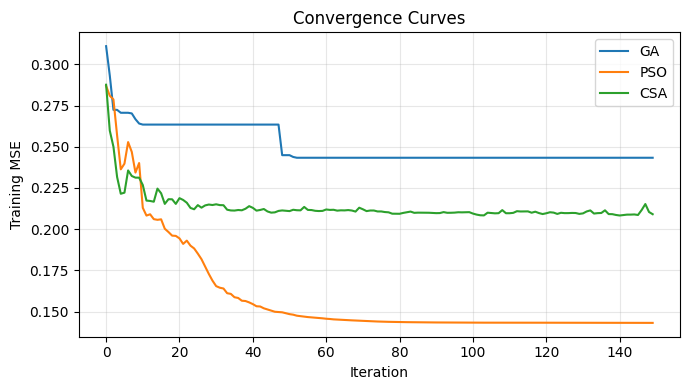

In [148]:
# ==========================================================
# 10. CONVERGENCE CURVES (MSE)
# ==========================================================
plt.figure(figsize=(7,4))
plt.plot(hist_ga, label="GA")
plt.plot(hist_pso, label="PSO")
plt.plot(hist_csa, label="CSA")
plt.xlabel("Iteration")
plt.ylabel("Training MSE")
plt.title("Convergence Curves")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figures/convergence_curves.png", dpi=300)
plt.show()


In [149]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# ----------------------------------------------------------
# Helper function to get predictions
# ----------------------------------------------------------
def get_predictions(best_weights, X):
    w = decode_weights(best_weights, X.shape[1], N_HIDDEN)
    y_prob = ann_forward(X, w).flatten()
    return (y_prob >= 0.5).astype(int)


# ----------------------------------------------------------
# Generate predictions for each optimizer
# ----------------------------------------------------------
preds = {
    "GA":  (
        get_predictions(best_ga,  X_tr),             # Train (balanced)
        get_predictions(best_ga,  X_test_selected)   # Test
    ),
    "PSO": (
        get_predictions(best_pso, X_tr),
        get_predictions(best_pso, X_test_selected)
    ),
    "CSA": (
        get_predictions(best_csa, X_tr),
        get_predictions(best_csa, X_test_selected)
    )
}


# ----------------------------------------------------------
# Build results table
# ----------------------------------------------------------
metrics = ["Accuracy", "Precision", "Recall", "F1-score"]
table = {}

for algo, (ytr_pred, yte_pred) in preds.items():

    # ---- Training metrics (SMOTE-balanced) ----
    table[f"{algo}-Train"] = [
        accuracy_score(y_tr, ytr_pred),
        precision_score(y_tr, ytr_pred, zero_division=0),
        recall_score(y_tr, ytr_pred, zero_division=0),
        f1_score(y_tr, ytr_pred, zero_division=0)
    ]

    # ---- Testing metrics (original distribution) ----
    table[f"{algo}-Test"] = [
        accuracy_score(y_test, yte_pred),
        precision_score(y_test, yte_pred, zero_division=0),
        recall_score(y_test, yte_pred, zero_division=0),
        f1_score(y_test, yte_pred, zero_division=0)
    ]

# ----------------------------------------------------------
# Save results
# ----------------------------------------------------------
df_results = pd.DataFrame(table, index=metrics)
df_results.to_csv("results_metrics.csv")

df_results


,GA-Train,GA-Test,PSO-Train,PSO-Test,CSA-Train,CSA-Test
Accuracy,0.693694,0.623188,0.846847,0.608696,0.671171,0.594203
Precision,0.666667,0.571429,0.859813,0.571429,0.666667,0.545455
Recall,0.774775,0.645161,0.828829,0.516129,0.684685,0.580645
F1-score,0.716667,0.606061,0.844037,0.542373,0.675556,0.562500


In [150]:
df_results.to_csv("results_metrics.csv")

In [151]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


def evaluate(best_weights, name):
    """
    Evaluate ANN model optimized by a given algorithm
    and plot confusion matrices for training and testing.
    """

    # Decode ANN weights using correct input dimension
    w = decode_weights(best_weights, X_tr.shape[1], N_HIDDEN)

    # Predictions
    ytr_pred = (ann_forward(X_tr, w).flatten() >= 0.5).astype(int)
    yte_pred = (ann_forward(X_test_selected, w).flatten() >= 0.5).astype(int)

    # Confusion matrices
    cm_train = confusion_matrix(y_tr, ytr_pred)
    cm_test  = confusion_matrix(y_test, yte_pred)

    # Plot
    fig, ax = plt.subplots(1, 2, figsize=(7, 3))

    sns.heatmap(cm_train, annot=True, fmt="d", cmap="Blues", ax=ax[0])
    sns.heatmap(cm_test,  annot=True, fmt="d", cmap="Blues", ax=ax[1])

    ax[0].set_title(f"{name} – Train (SMOTE-balanced)")
    ax[1].set_title(f"{name} – Test (Unseen data)")

    ax[0].set_xlabel("Predicted")
    ax[0].set_ylabel("True")
    ax[1].set_xlabel("Predicted")
    ax[1].set_ylabel("True")

    plt.tight_layout()
    plt.savefig(f"figures/confusion_{name}.png", dpi=300)
    plt.show()

    return ytr_pred, yte_pred


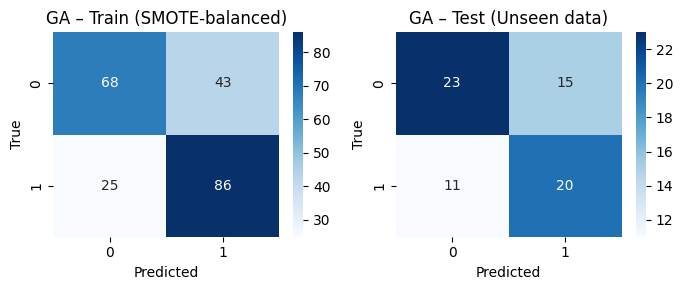

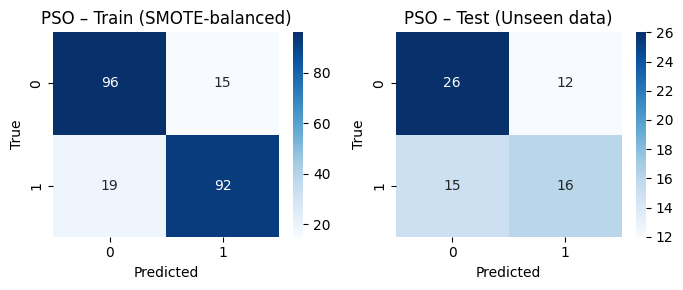

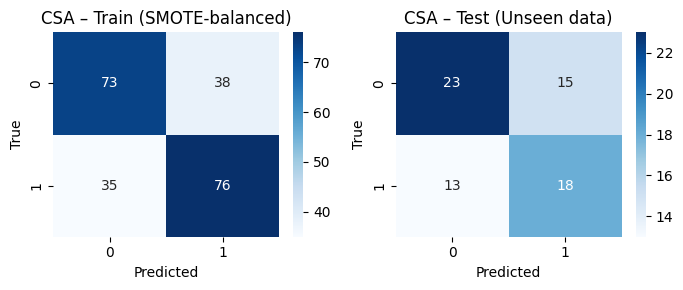

In [152]:
preds = {
    "GA":  evaluate(best_ga,  "GA"),
    "PSO": evaluate(best_pso, "PSO"),
    "CSA": evaluate(best_csa, "CSA")
}


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Metrics and algorithms
metrics = df_results.index.tolist()
algorithms = ["GA", "PSO", "CSA"]

x = np.arange(len(metrics))
width = 0.22          # bar width
gap = 0.02            # extra distance between algorithms

plt.figure(figsize=(8, 3))

# Plot training-only bars with spacing
for i, algo in enumerate(algorithms):
    offset = i * (width + gap)
    plt.bar(
        x + offset,
        df_results[f"{algo}-Train"],
        width,
        label=f"{algo}-Train"
    )

# Axis formatting
plt.xticks(x + (width + gap), metrics)
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.title("Training Performance of Metaheuristic-Optimized ANN Models")
plt.legend(ncol=3, fontsize=9)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("figures/performance_bar_chart_train_only.png", dpi=300)
plt.show()


In [ ]:
import json

# Decode PSO best weights using feature-selected input dimension
w1, b1, w2, b2 = decode_weights(best_pso, X_tr.shape[1], N_HIDDEN)

# Convert to JSON-serializable format
weights = {
    "w1": w1.tolist(),
    "b1": b1.tolist(),
    "w2": w2.flatten().tolist(),
    "b2": float(b2)
}

# Save as JSON
with open("pso_ann_weights.json", "w") as f:
    json.dump(weights, f)

print("PSO ANN weights saved successfully as 'pso_ann_weights.json'.")


In [ ]:
# ==========================================================
# CELL 1: Calculate min/max for each feature
# ==========================================================
import numpy as np

# If you want original values before scaling:
# feature_min_original = scaler.inverse_transform(X_train_selected).min(axis=0)
# feature_max_original = scaler.inverse_transform(X_train_selected).max(axis=0)

# Otherwise, use scaled values (current ANN uses scaled inputs)
feature_min = np.min(X_train_selected, axis=0)
feature_max = np.max(X_train_selected, axis=0)

# Detect integer-like features (all values are integers after rounding)
# You can customize this based on domain knowledge, e.g., age, score columns
integer_features = []
for i in range(X_train_selected.shape[1]):
    # If all scaled values round to integers -> treat as integer input
    if np.all(np.round(X_train_selected[:, i]) == X_train_selected[:, i]):
        integer_features.append(True)
    else:
        integer_features.append(False)

# Save for later use in HTML creation
feature_ranges = {
    "min": feature_min.tolist(),
    "max": feature_max.tolist(),
    "is_integer": integer_features
}

print("Feature ranges prepared for HTML webpage:")
for i, f in enumerate(selected_features):
    print(f"{f}: min={feature_ranges['min'][i]:.2f}, max={feature_ranges['max'][i]:.2f}, integer={feature_ranges['is_integer'][i]}")


In [ ]:
# ==========================================================
# CELL 2: Generate HTML webpage with feature names and ranges
# ==========================================================
import json
from pathlib import Path

# Number of features
n_features = len(selected_features)

# Decode PSO best weights
w1, b1, w2, b2 = decode_weights(best_pso, n_features, N_HIDDEN)

# Convert weights to JSON
weights = {
    "w1": w1.tolist(),
    "b1": b1.tolist(),
    "w2": w2.flatten().tolist(),
    "b2": float(b2)
}

# HTML template
html_template = f"""
<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<title>Diagnosis of OSA using Evolutionary NN model Developed by Alaa Sheta</title>
<style>
body {{ font-family: Arial, sans-serif; margin: 20px; background-color: #f4f4f9; }}
h2 {{ color: #2c3e50; }}
#inputGrid {{ display: grid; grid-template-columns: repeat(3, 1fr); gap: 15px; margin-bottom: 20px; }}
.feature-box {{ background-color: #ecf0f1; padding: 10px; border-radius: 8px; text-align: left; }}
label {{ display: block; font-weight: bold; margin-bottom: 3px; }}
input, select {{ width: 100%; padding: 5px; margin-bottom: 5px; border-radius: 5px; border: 1px solid #bdc3c7; }}
button {{ background-color: #2980b9; color: white; padding: 10px 15px; border: none; border-radius: 5px; cursor: pointer; font-weight: bold; }}
button:hover {{ background-color: #3498db; }}
#result {{ margin-top: 15px; font-weight: bold; font-size: 1.1em; color: #c0392b; }}
</style>
</head>
<body>

<h2>Diagnosis of OSA using Evolutionary NN model Developed by Alaa Sheta</h2>

<div id="inputGrid"></div>

<button onclick="predict()">Predict</button>
<div id="result"></div>

<script>
// ANN weights
const weights = {json.dumps(weights)};

// Feature names and ranges
const featureNames = {json.dumps(selected_features)};
const featureMin = {json.dumps(feature_ranges['min'])};
const featureMax = {json.dumps(feature_ranges['max'])};
const featureInteger = {json.dumps(feature_ranges['is_integer'])};

const nFeatures = featureNames.length;

// Create input grid
const grid = document.getElementById("inputGrid");
for (let i = 0; i < nFeatures; i++) {{
    const box = document.createElement("div");
    box.className = "feature-box";

    const label = document.createElement("label");
    label.innerText = `${{featureNames[i]}} (Min: ${{featureMin[i].toFixed(2)}}, Max: ${{featureMax[i].toFixed(2)}})`;
    box.appendChild(label);

    const input = document.createElement("input");
    input.type = "number";
    input.id = `feat${{i}}`;
    input.min = featureMin[i];
    input.max = featureMax[i];
    input.value = ((featureMin[i] + featureMax[i]) / 2).toFixed(2);
    input.step = featureInteger[i] ? "1" : "any";  // only integers for integer features
    box.appendChild(input);

    grid.appendChild(box);
}}

// Activation functions
function sigmoid(x) {{ return 1 / (1 + Math.exp(-x)); }}
function tanh(x) {{ return Math.tanh(x); }}

// Predict function
function predict() {{
    let x = [];
    for (let i = 0; i < nFeatures; i++) {{
        x.push(parseFloat(document.getElementById(`feat${{i}}`).value));
    }}

    // Hidden layer
    let a1 = [];
    for (let j = 0; j < weights.b1.length; j++) {{
        let sum = weights.b1[j];
        for (let i = 0; i < nFeatures; i++) {{
            sum += x[i] * weights.w1[i][j];
        }}
        a1.push(tanh(sum));
    }}

    // Output layer
    let z2 = weights.b2;
    for (let j = 0; j < weights.w2.length; j++) {{
        z2 += a1[j] * weights.w2[j];
    }}

    let y_hat = sigmoid(z2);
    let label = y_hat > 0.5 ? "Apnea" : "No Apnea";
    document.getElementById("result").innerText =
        `Prediction: ${{label}}, Probability: ${{y_hat.toFixed(3)}}`;
}}
</script>

</body>
</html>
"""

# Save HTML file
Path("pso_ann_webpage_feature_grid.html").write_text(html_template)
print("✅ Interactive HTML webpage generated: pso_ann_webpage_feature_grid_updated.html")
